In [ ]:
#!pip install numpy geopandas rasterio shapely matplotlib --break-system-packages

In [1]:
#import required packages
import numpy as np
import geopandas as gpd
import rasterio
from shapely.geometry import LineString
import matplotlib.pyplot as plt

In [2]:
#define paths
rasterPath = '../Rst/topoBath_16N.tif'
sectionPath = '../Shp/Model/crossSectionSW3.shp'

63.02899065160332


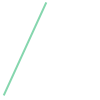

In [3]:
#create the cross section

#open the shapefile
sectionDf = gpd.read_file(sectionPath)
sectionGeom = sectionDf.geometry.iloc[0]
print(sectionGeom.length)
sectionGeom

In [4]:
#sample points over the cross section
nSamples = 65
distances = np.linspace(0, sectionGeom.length, nSamples)
points = [sectionGeom.interpolate(d) for d in distances]
coords = [(p.x, p.y) for p in points]
coords[:5]

[(697608.8661485323, 4345720.540550129),
 (697609.2777608514, 4345721.435235239),
 (697609.6893731706, 4345722.32992035),
 (697610.1009854898, 4345723.22460546),
 (697610.512597809, 4345724.11929057)]

In [5]:
#extract elevations and elevArray
elevDs = rasterio.open(rasterPath) 
elevations = np.array([val[0] for val in elevDs.sample(coords)])
elevations[:5]

array([149.7938385 , 149.77992249, 149.79277039, 149.69490051,
       149.62817383])

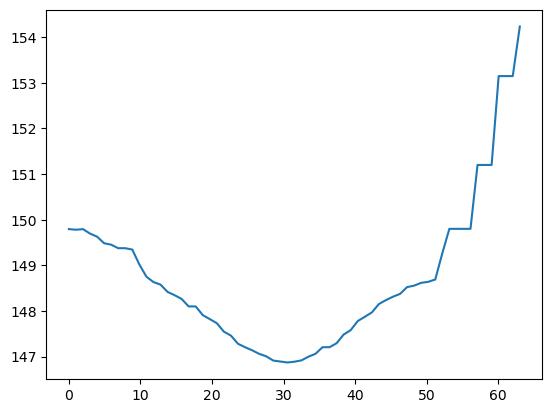

In [6]:
#plot a figure of the cross section
fig, ax = plt.subplots()
ax.plot(distances, elevations)

In [7]:
#calculate average slope

elevArray = elevDs.read(1).astype(float)

#check pixel size
transform = elevDs.transform
transform

Affine(1.0, 0.0, 697242.5845,
       0.0, -1.0, 4345888.712)

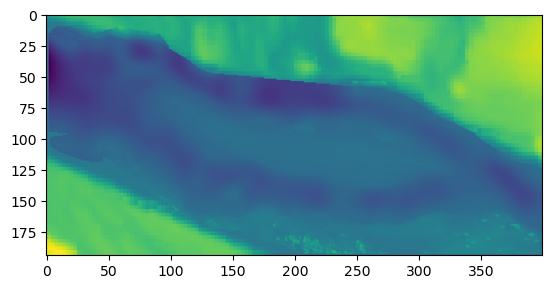

In [8]:
plt.imshow(elevArray)

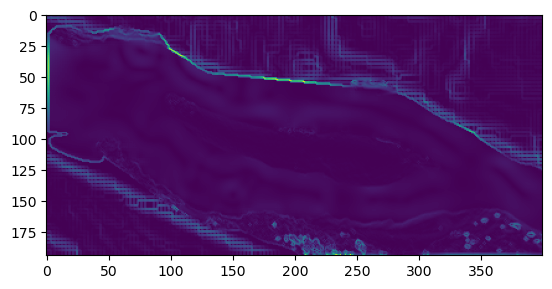

In [9]:
#compute gradients
pixelSize = transform[0]
dy, dx = np.gradient(elevArray,pixelSize)
slopeArray = np.sqrt(dx**2 + dy**2)
plt.imshow(slopeArray) 

In [10]:
#check sizes of rasters
print(elevArray.shape)
print(slopeArray.shape)

(194, 400)
(194, 400)


In [11]:
np.mean([1,2,3])

2.0

In [12]:
def calculateAverageSlope(elevations, waterStage):
    slopeList = []
    for index, value in enumerate(elevations):
        if value < waterStage:
            row, col = elevDs.index(coords[index][0],coords[index][1])
            slopeList.append(slopeArray[row,col])
    meanSlope = np.mean(slopeList)
    return meanSlope

In [13]:
# calculate the cross section area (SA) and the wetted perimeter (P)
dx = distances[1] - distances[0]

def calculateAreaPerimeter(waterStage):
    sectionArea = 0 #m2
    wettedPerimeter = 0 #m.

    #this is a calculation over trapezoids
    for i in range(len(elevations)-1):
        z1 = elevations[i]
        z2 = elevations[i+1]
        
        #skip calculation if elevations are above the water stage
        if (z1 >= waterStage) and (z2 >= waterStage):
            continue #skips this iteration

        #water depths at both edges of the trapezoid
        d1 = max(0, waterStage - z1)
        d2 = max(0, waterStage - z2)

        #segment area as trapezoidal area
        segArea = 0.5 * (d1 + d2)*dx

        #add the partial area to the total area
        sectionArea += segArea

        #calculate the part of the wetted perimeter
        dz = z2 - z1
        segPerimeter = np.sqrt(dx**2 + dz**2)

        #add the partial wetted perimeter to the total perimeter
        wettedPerimeter += segPerimeter  

    #print('The section areas is %.2f m2 and the wettedPerimeter is %.2f m'%(sectionArea,wettedPerimeter))

    return sectionArea, wettedPerimeter

def calculateManningFlow(sectionArea, wettedPerimeter, manningCoef, slope):
    hydraulicRadius = sectionArea / wettedPerimeter
    discharge = sectionArea * (hydraulicRadius**(2/3)) * np.sqrt(slope)
    return discharge


In [14]:
#calculation over all SW3 records

import pandas as pd

#open the observed data, select sheet and clip columns
dfRaw = pd.read_excel('../xls/Observed_Head.xlsx', sheet_name='Water Level Head & Temp')
dfRaw = dfRaw.rename(columns={'Unnamed: 45':'ElevRaw'})
dfRaw = dfRaw.iloc[2:,44:46]
dfRaw = dfRaw.set_index('SW2')
dfRaw['waterStage'] = dfRaw.ElevRaw + 3.4 #fix on the datum
dfRaw.head()

/home/hatari/.local/lib/python3.12/site-packages/pandas/core/indexes/base.py:7588: FutureWarning: Dtype inference on a pandas object (Series, Index, ExtensionArray) is deprecated. The Index constructor will keep the original dtype in the future. Call `infer_objects` on the result to get the old behavior.
  return Index(sequences[0], name=names)


,ElevRaw,waterStage
SW2,,
2023-01-01 00:00:00,145.262786,148.662786
2023-01-01 01:00:00,145.273004,148.673004
2023-01-01 02:00:00,145.292494,148.692494
2023-01-01 03:00:00,145.302354,148.702354
2023-01-01 04:00:00,145.318458,148.718458


In [15]:
dischargeList = []
i = 0
for index, row in dfRaw.iterrows():
    meanSlope = calculateAverageSlope(elevations, row.waterStage)
    sectionArea, wettedPerimeter = calculateAreaPerimeter(row.waterStage)
    if i // 100 == 0:
        print('The section areas is %.2f m2. The wettedPerimeter is %.2f m'%(sectionArea,wettedPerimeter))
        print('The average slope is %.2f'%(meanSlope))
        print('-------')
    i+=1
    discharge = calculateManningFlow(sectionArea, wettedPerimeter, 0.035, meanSlope)
    dischargeList.append(discharge)

The section areas is 37.03 m2. The wettedPerimeter is 40.61 m
The average slope is 0.10
-------
The section areas is 37.43 m2. The wettedPerimeter is 40.61 m
The average slope is 0.10
-------
The section areas is 38.20 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 38.60 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.25 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.62 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.82 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.97 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.88 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.79 m2. The wettedPerimeter is 41.75 m
The average slope is 0.11
-------
The section areas is 39.70 m2. The wette

In [ ]:
dfRaw['flowm3s'] = dischargeList
dfRaw.head()

In [ ]:
fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(dfRaw.index, dfRaw.waterStage, label='Water Stage', color = 'crimson')
ax1.set_xlabel('Date')
ax1.set_ylabel('Water Stage (m)')

ax2 = ax1.twinx()
ax2.plot(dfRaw.index, dfRaw.flowm3s, label='Flow m3/s', color ='slateblue')
ax2.set_ylabel('Flow (m/s)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2)
#ax2.legend()
ax1.grid()

plt.show()

In [ ]:
dfRaw.to_csv('../Xls/flowMiamiRiver.csv')